In [ ]:
import numpy as np
import pandas as pd
# Ψ
# 指定修饰 (Mod) 和未修饰 (Unmod) 数据文件路径
unmoda = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.a.tsv"
unmodc = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.c.tsv"
unmodu = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.u.tsv"
unmodg = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.g.tsv"
m6a = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.m6a.tsv"
m1a = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.m1a.tsv"
inosine = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.inosine.tsv"
m5c = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.m5c.tsv"
hm5c = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.hm5c.tsv"
m7g = "/root/sunxh/WaveCrossMamba/dataset/IVT_m7G.feature.tsv"
psu = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.psu.tsv"

def load_predict_data(file, data_length=1000):
    X = []
    count = 0
    with open(file, "r") as f:
        for line in f:
            line = line.rstrip()
            items = line.split("\t")
            kmer = items[3]
            mean = np.array([float(item) for item in items[4].split("|")])
            std = np.array([float(item) for item in items[5].split("|")])
            intensity = np.array([float(item) for item in items[6].split("|")])
            dwell = np.array([float(item) for item in items[7].split("|")])/200
            basequality = np.array([float(item) for item in items[8].split("|")])
            features = mean + std + dwell + intensity+dwell+basequality
            X.append(features)
            count += 1
            if count >= data_length: 
                break
    return np.array(X)  
# 创建 DataFrame
datasets = {
    "normalG": inosine,
    "normalU": unmodu,
    "normalC": unmodc,
    "normalA": unmoda,
    "m6a": m6a,    
    "m1a": m1a,
    "m5c": m5c,
    "hm5c": hm5c,
    "psu": psu,
    "m7g": m7g,
    "inosine": inosine,
}
x_list,y_list = [],[]
for label,path in datasets.items():
    data = load_predict_data(path)
    x_list.append(data)
    y_list.extend([label]*len(data))
x = np.vstack(x_list)
y = np.array(y_list)
print(x.shape)
print(y.shape)

(11000, 5)
(11000,)


In [1]:
# 选择因变量（y）
# 整个信号曲线/统计特征，时间序列降维后特征（pcd降维到2d）
import numpy as np
unmoda = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.a.tsv"
unmodc = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.c.tsv"
unmodu = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.u.tsv"
unmodg = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.unmod.g.tsv"
m6a = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.m6a.tsv"
m1a = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.m1a.tsv"
inosine = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.inosine.tsv"
m5c = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.m5c.tsv"
hm5c = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.hm5c.tsv"
m7g = "/root/sunxh/WaveCrossMamba/dataset/IVT_m7G.feature.tsv"
psu = "/root/sunxh/WaveCrossMamba/dataset/fine.ivt.psu.tsv"
kmer_encode_dic={'A': 0, "C": 1, "G": 2, "T": 3}

def load_predict_data(file, max_length=500, signal_length=500):
    X, signals = [], []
    count = 0
    with open(file) as f:
        for line in f:
            line = line.rstrip()
            items = line.split("\t")

            raw_signals = "|".join(items[9:14]).split("|")
            signal = np.array([float(s) for s in raw_signals])



            if len(signal) < signal_length:
                signal = np.pad(signal, (0, signal_length - len(signal)), mode='constant')
            else:
                signal = signal[:signal_length]

            kmer = items[3]
            kmer = np.array([kmer_encode_dic[base] for base in kmer])
            mean = np.array([float(item) for item in items[4].split("|")])
            std = np.array([float(item) for item in items[5].split("|")])
            intense = np.array([float(item) for item in items[6].split("|")])
            dwell = np.array([float(item) for item in items[7].split("|")]) / 200
            base_quality = np.array([float(item) for item in items[8].split("|")]) / 40

            x = np.hstack([kmer, mean, std, intense, dwell, base_quality])
            X.append(x)
            signals.append(signal)
            count += 1
            if count >= max_length:
                break
    return np.array(X), np.array(signals)

datasets = {
    "normalA": unmoda,
    "m6a": m6a,    
    "m1a": m1a,
}
x_list, y_list, signal_list = [], [], []

for label, path in datasets.items():
    data, signals = load_predict_data(path, max_length=100, signal_length=500)
    print(f"{label} data shape: {data.shape}, signals shape: {signals.shape}")
    
    x_list.append(data)
    signal_list.append(signals)
    y_list.extend([label] * len(data))


x = np.vstack(x_list)
signal = np.vstack(signal_list)
y = np.array(y_list)


print("Final shapes:")
print("x:", x.shape)
print("y:", y.shape)
print("signal:", signal.shape)

normalA data shape: (100, 30), signals shape: (100, 500)
m6a data shape: (100, 30), signals shape: (100, 500)
m1a data shape: (100, 30), signals shape: (100, 500)
Final shapes:
x: (300, 30)
y: (300,)
signal: (300, 500)


savefig() got unexpected keyword argument "trainsparent" which is no longer supported as of 3.3 and will become an error two minor releases later


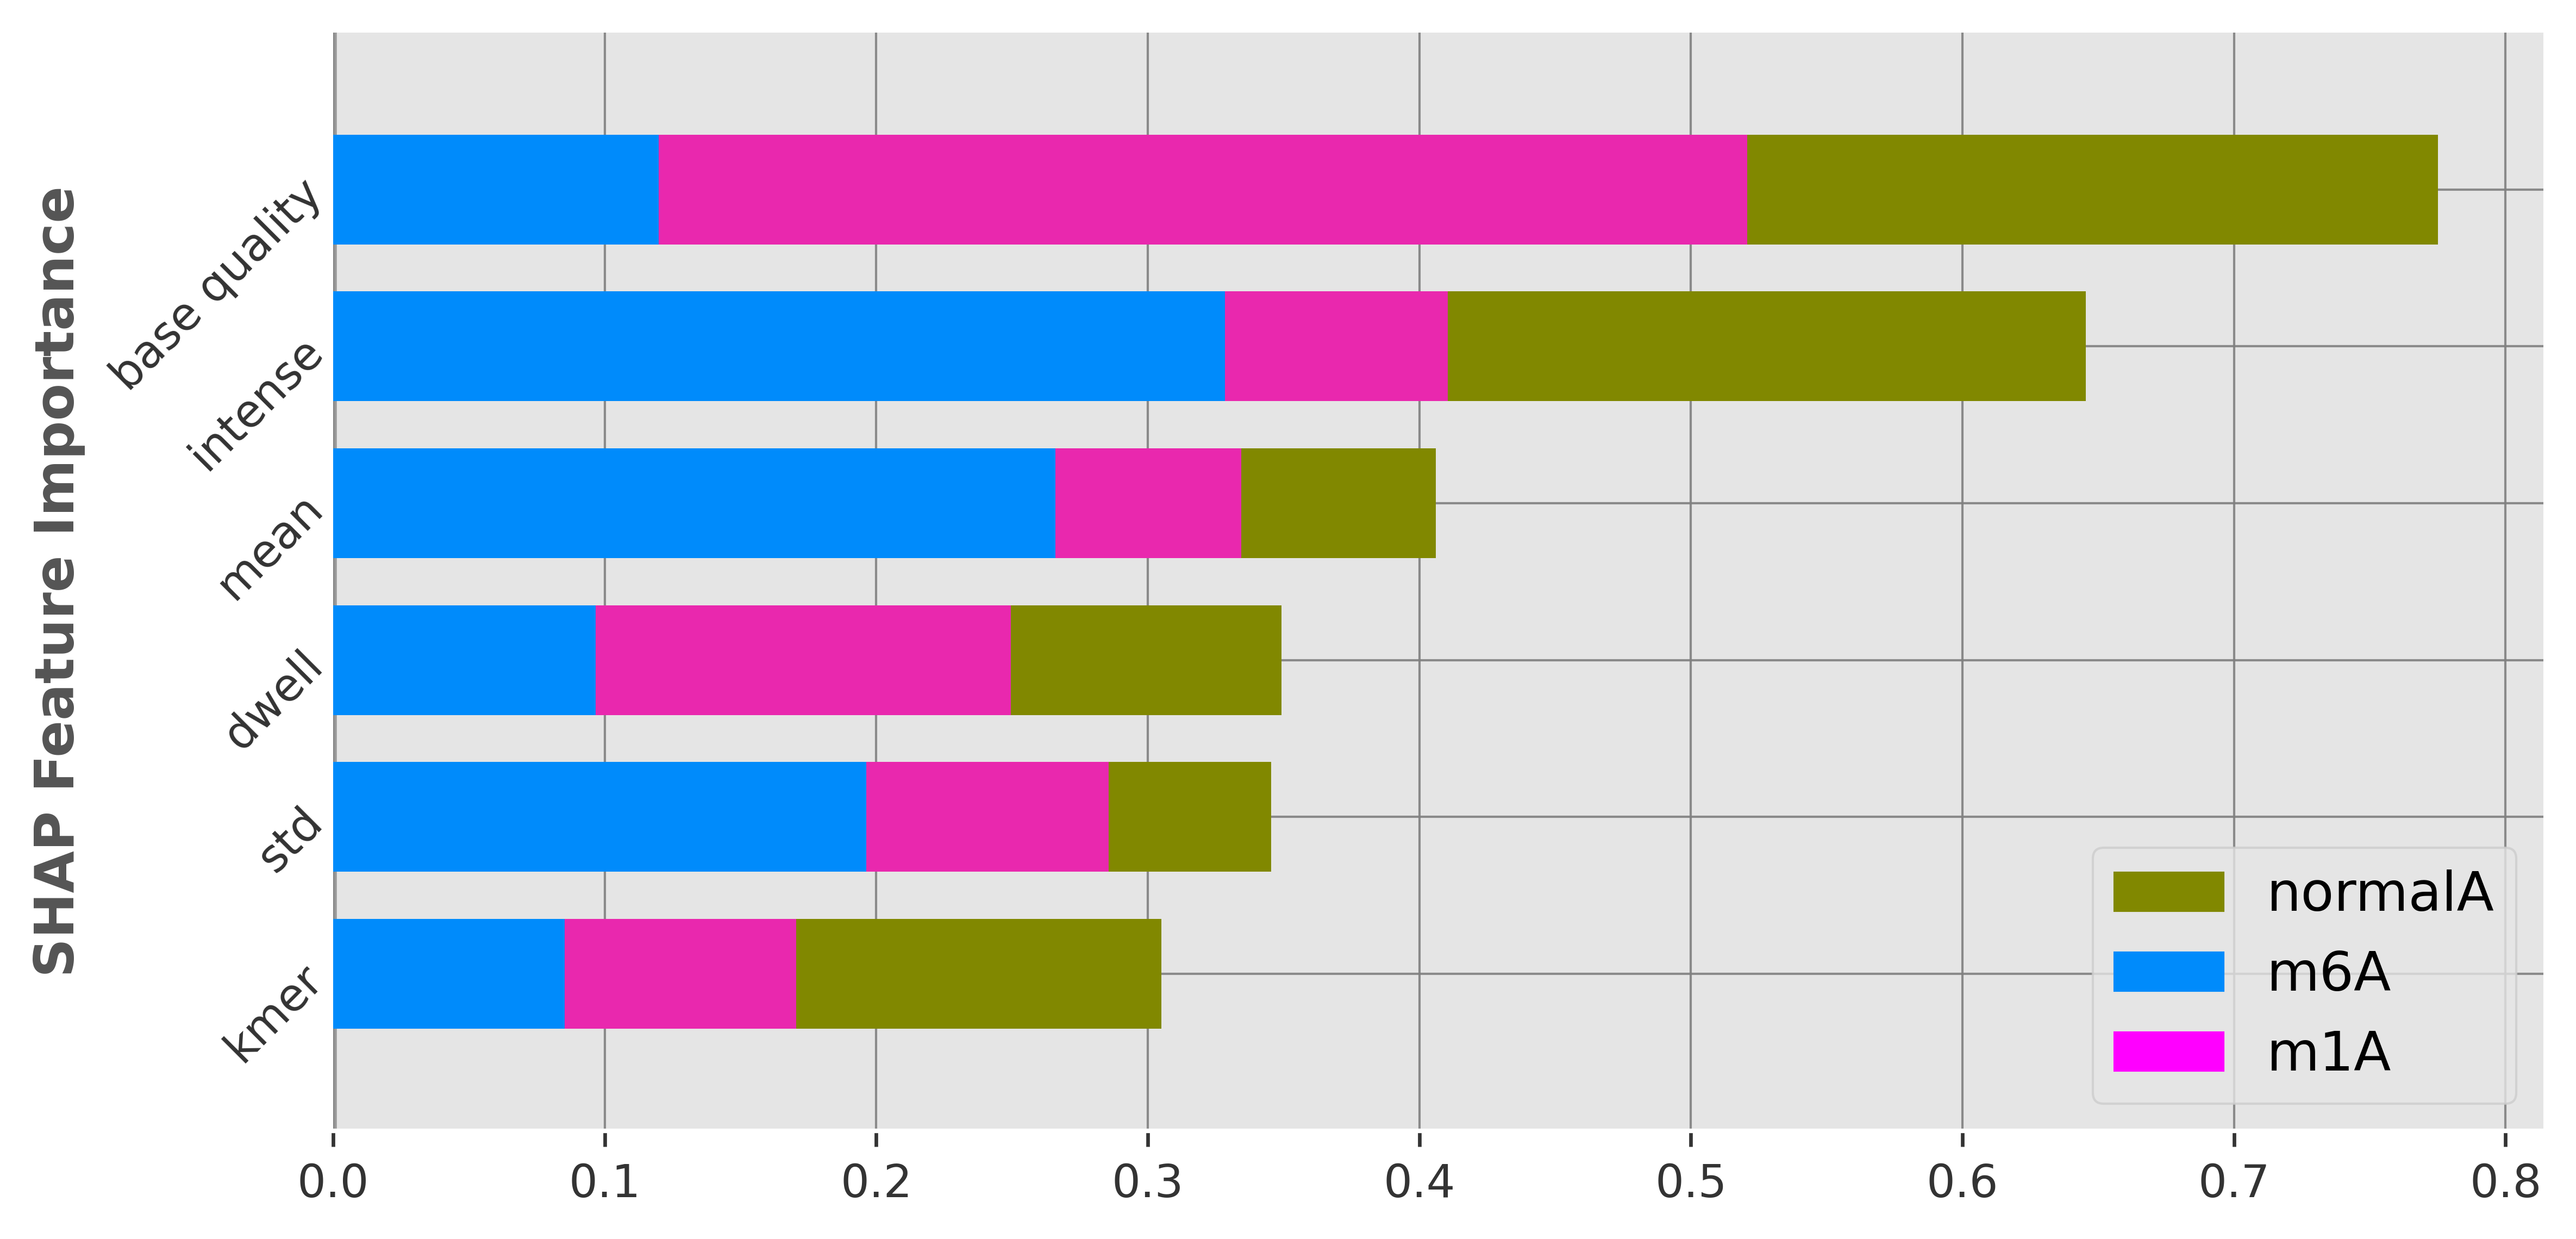

In [3]:
import numpy as np
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

plt.style.use('ggplot')
datasets = {
    "normalC": unmodc,
    "m5C": m5c,    
    "hm5C": hm5c,
}

x_list, y_list, signal_list, kmer_list = [], [], [], []


for label, path in datasets.items():
    data, signals = load_predict_data(path, max_length=500, signal_length=500)
    
    kmer_strings = [''.join(map(str, row[:5].astype(int))) for row in data]
    kmer_list.extend(kmer_strings)

    mean_mid = data[:, 5+2]
    std_mid = data[:, 10+2]
    intense_mid = data[:, 15+2]
    dwell_mid = data[:, 20+2]
    base_quality_mid = data[:, 25+2]
    filtered_features = np.column_stack([
        mean_mid, std_mid, intense_mid, dwell_mid, base_quality_mid
    ])
        
    x_list.append(filtered_features)
    signal_list.append(signals)
    y_list.extend([label] * len(data))

x = np.vstack(x_list)
signal = np.vstack(signal_list)
y = np.array(y_list)

le = LabelEncoder()
kmer_encoded = le.fit_transform(kmer_list).reshape(-1, 1)
x = np.hstack([kmer_encoded, x])
unique_labels = list(set(y))
label_to_int = {label: i for i, label in enumerate(unique_labels)}
clusters = np.array([label_to_int[label] for label in y])
feature_names = [
    "kmer",
    "mean", "std", "intense", "dwell", "base quality"
]
X_df = pd.DataFrame(x, columns=feature_names)

shap_values = wattMamaba.shap_values(X_df)
normalA_color = (129/255,136/255,  0/255)
m6a_color = (0/255,139/255,251/255)
m1a_color =(233/255,40/255,174/255)
import matplotlib.patches as mpatches
plt.figure(figsize=(5, 3),dpi=600,facecolor='none')
shap.summary_plot(shap_values, X_df, feature_names=feature_names, plot_type="bar", show=False)
plt.title("", fontsize=16, fontweight="bold")
ax = plt.gca() 
plt.xlabel("")
plt.ylabel("SHAP Feature Importance",fontweight="bold",fontname="Times New Roman")  
plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=45,fontsize=10)
plt.gca().tick_params(axis='y', pad=-3)
# **手动修改图例颜色**
legend_patches = [
    mpatches.Patch(color=normalA_color, label="normalA"),  
    mpatches.Patch(color=m6a_color, label="m6A"),  
    mpatches.Patch(color="magenta", label="m1A")  
]
ax.grid(True,color='gray', linestyle='-', linewidth=0.5, alpha=0.9)
plt.legend(handles=legend_patches, fontsize=12)
plt.tight_layout()
plt.savefig("/root/sunxh/WaveCrossMamba/result_pdf_pdf_pdf_pdf/shap_normalA.pdf", dpi=300, bbox_inches='tight',trainsparent=True)
plt.show()


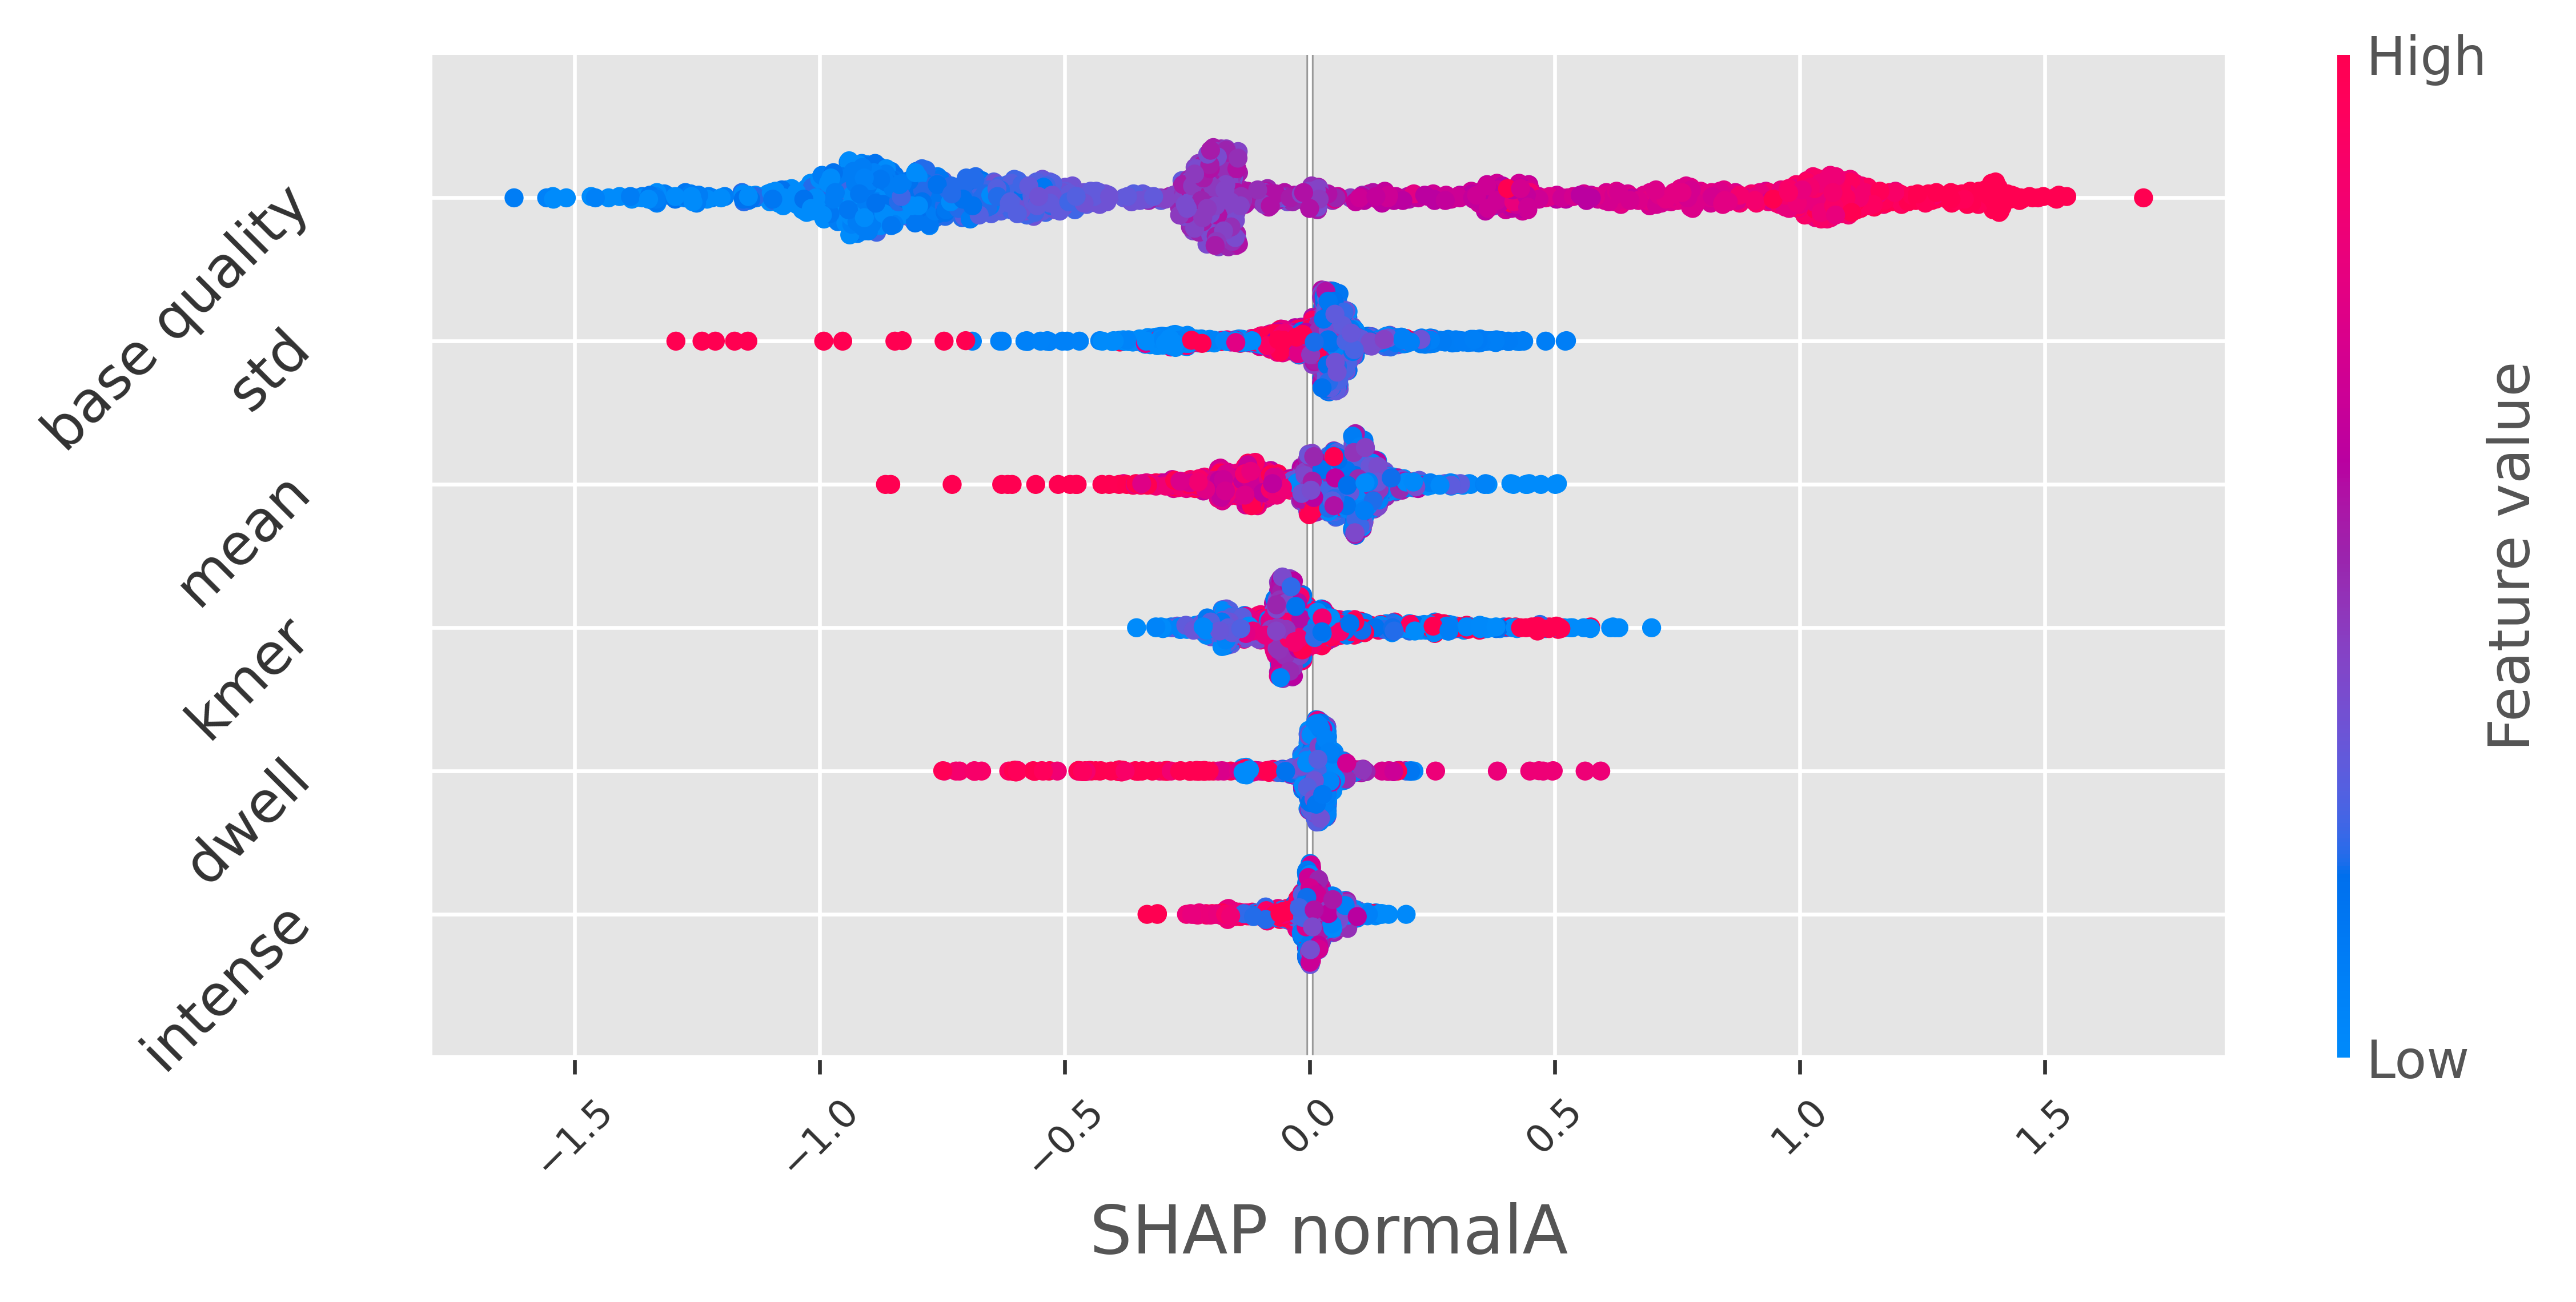

In [3]:
class_index = 0 
plt.figure(figsize=(4, 3),dpi=600,facecolor='none')
shap.summary_plot(shap_values[class_index], X_df, feature_names=feature_names, plot_type="dot", show=False)
plt.title(f"", fontsize=16, fontweight="bold")
plt.xlabel("SHAP normalA", fontsize=14)
plt.ylabel("")
plt.xticks(rotation=45, fontsize=8)
plt.yticks(rotation=45,fontsize=12)
plt.tight_layout()
plt.savefig(f"shap_beeswarm_class{class_index}.png", dpi=600, bbox_inches='tight')
plt.show()